In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import warnings

In [2]:
warnings.filterwarnings('ignore')

Problem Statement--
In this dataset ,we have to analyze and predict whether we should give loan to the person or not ,on the behave of given information

In [3]:
#read the dataset
df=pd.read_csv('Data/loan_data.csv')

In [4]:
#first make copy of original dataset
df_copy=df.copy()

In [5]:
df_copy

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [6]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [7]:
#columns wise missing values 
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [8]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [9]:
#perctantage of missing values in columns
df.isnull().sum()/df.shape[0]*100

Loan_ID              0.000000
Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
Self_Employed        5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.583062
Loan_Amount_Term     2.280130
Credit_History       8.143322
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [10]:
# checking duplicate values
df.duplicated().sum()

0

Drop the loan id columns cuz it doesn't have any meaningful data

In [11]:
df.drop(columns='Loan_ID',axis=1,inplace=True)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             601 non-null    object 
 1   Married            611 non-null    object 
 2   Dependents         599 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      582 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         592 non-null    float64
 8   Loan_Amount_Term   600 non-null    float64
 9   Credit_History     564 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 57.7+ KB


In [13]:
df.shape

(614, 12)

Separate the categorical and Numerical Columns

In [14]:
numerical=[col for col in df.columns if df[col].dtype!="object"]
categorical=[col for col in df.columns if df[col].dtype=="object"]

print('numerical features ' ,len(numerical))
print('numerical features ',len(categorical))

numerical features  5
numerical features  7


Univaraiate analysis

In [15]:
#see the proportion of  category
for i in categorical:
    print(df[i].value_counts(normalize=True)*100)
    print("------------------------")

Gender
Male      81.364393
Female    18.635607
Name: proportion, dtype: float64
------------------------
Married
Yes    65.139116
No     34.860884
Name: proportion, dtype: float64
------------------------
Dependents
0     57.595993
1     17.028381
2     16.861436
3+     8.514190
Name: proportion, dtype: float64
------------------------
Education
Graduate        78.175896
Not Graduate    21.824104
Name: proportion, dtype: float64
------------------------
Self_Employed
No     85.910653
Yes    14.089347
Name: proportion, dtype: float64
------------------------
Property_Area
Semiurban    37.947883
Urban        32.899023
Rural        29.153094
Name: proportion, dtype: float64
------------------------
Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64
------------------------


univariate analysis on numerical columnns

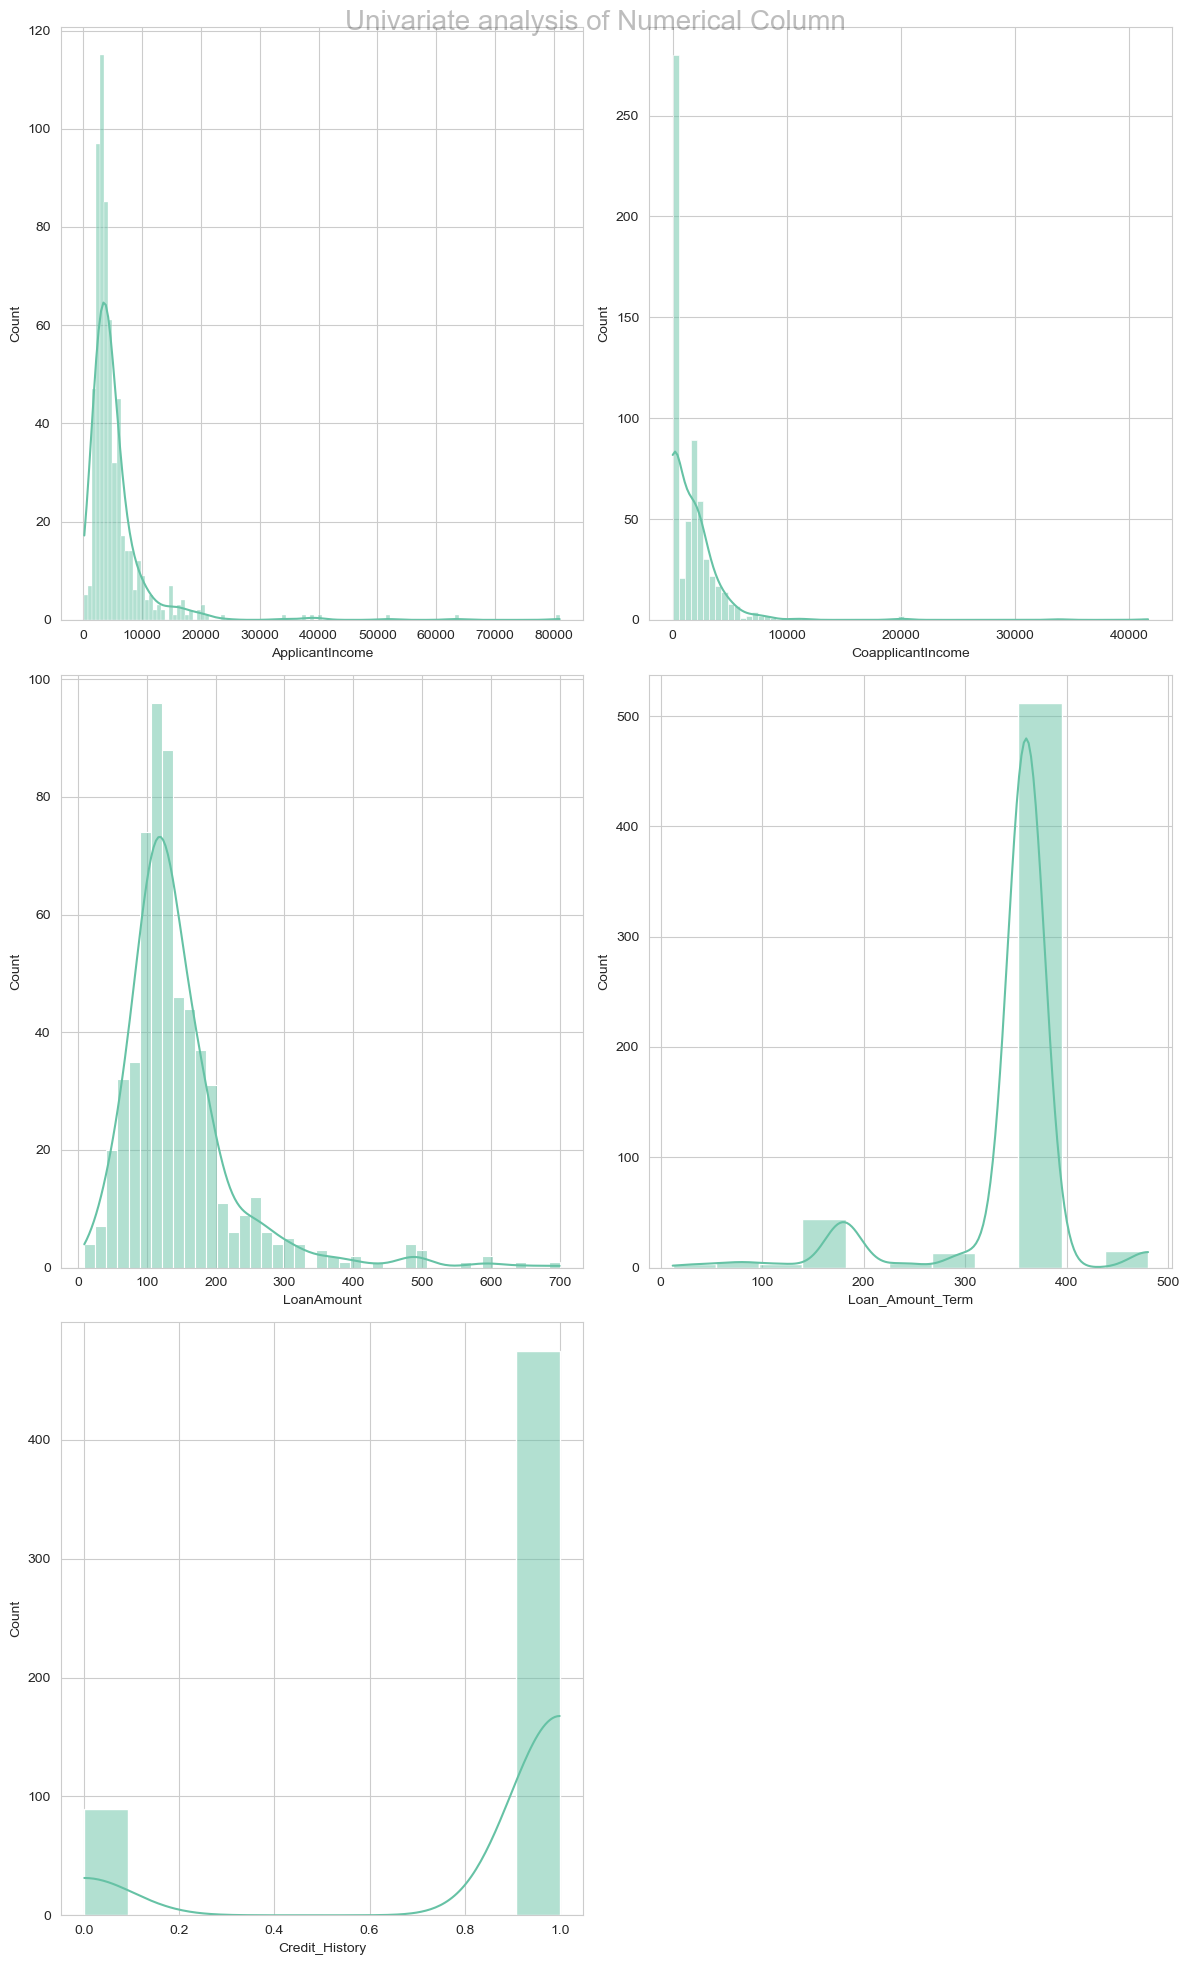

In [16]:
sns.set_palette('Set2')
sns.set_style('whitegrid')
plt.figure(figsize=(12,20))
plt.suptitle('Univariate analysis of Numerical Column',fontsize=20,alpha=0.3)
for i in range(len(numerical)):
    plt.subplot(3,2,i+1)
    sns.histplot(x=df[numerical[i]],kde=True)
    plt.xlabel(numerical[i])
    plt.tight_layout()
plt.show()

Report of Univaraiate Analysis---

Applicantincome--> This column are right skwewed and presence of outliers also

coapplicantincome-->This column are also right skewed and it's also have an outlier

loanamount-->This column are also right skewed and it's also have an outlier

loan_amount_term-->This column are left skewed and have outliers 

Credit_History--->In this column most people have credit history close to 1,which describe loan repayment score

Univarite analysis on Categorical features

In [17]:
categorical

['Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Property_Area',
 'Loan_Status']

Note-->if any of columns has more than 10 unique values then we considered them as numerical columns...

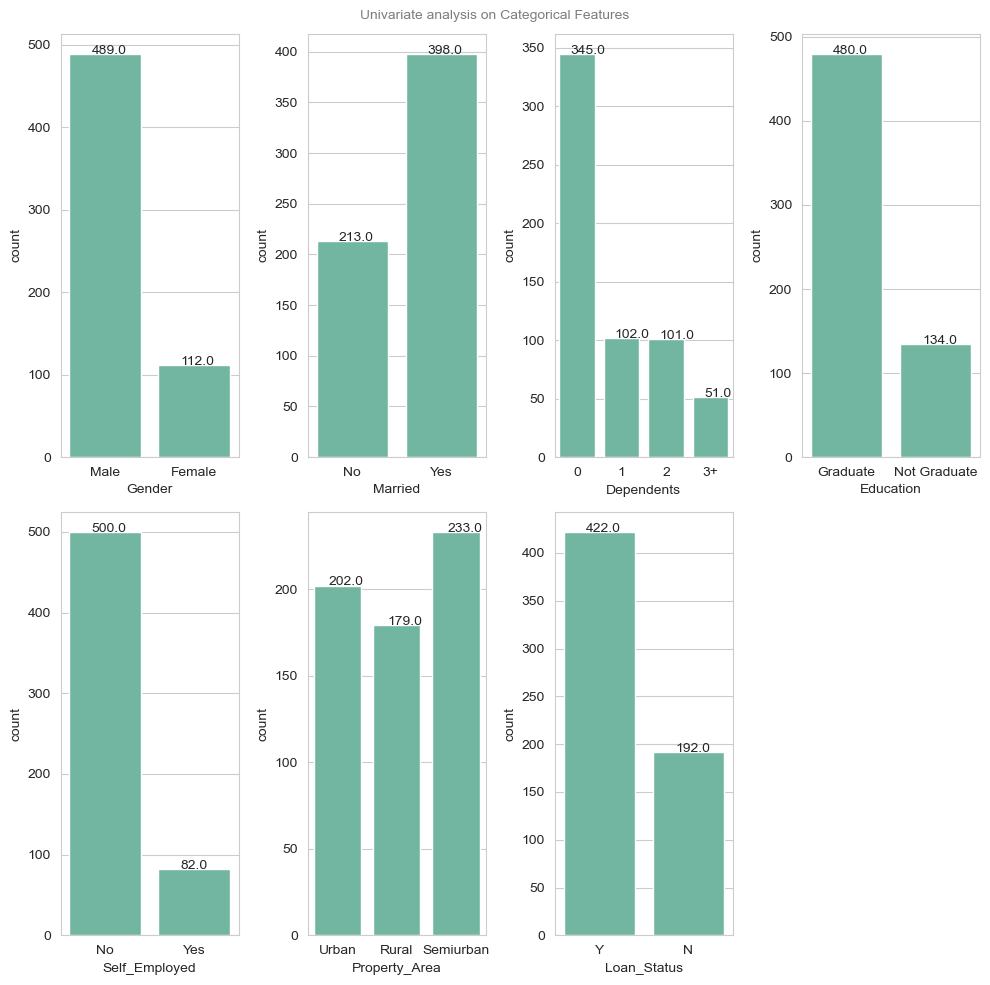

In [18]:
plt.figure(figsize=(10,10))
plt.suptitle('Univariate analysis on Categorical Features',fontsize=10,alpha=0.6)
for i in range(len(categorical)):
    plt.subplot(2,4,i+1)
    ax=sns.countplot(x=df[categorical[i]])
    if df[categorical[i]].value_counts().count()<10:
        for p in ax.patches:
            ax.annotate('{:.1f}'.format(p.get_height()),(p.get_x()+0.25,p.get_height()+0.1))
        plt.xlabel(categorical[i])
        plt.tight_layout()
plt.show()
        

Report:

Gender-->Male has applied more for loan in comparison to women

Married--->Married people has applied more for loan rather than single one

Dependents--->People who are single are more likely applied loan followed by 1,2,3

Education--->Graduate people are applied more for loan

Self_Employeed-->people who have job ,they are applied for loan

Property_area-->These are not distinguish 

Loan_status-->most people have successfully gets loan

Multivaraite analysis

<Axes: >

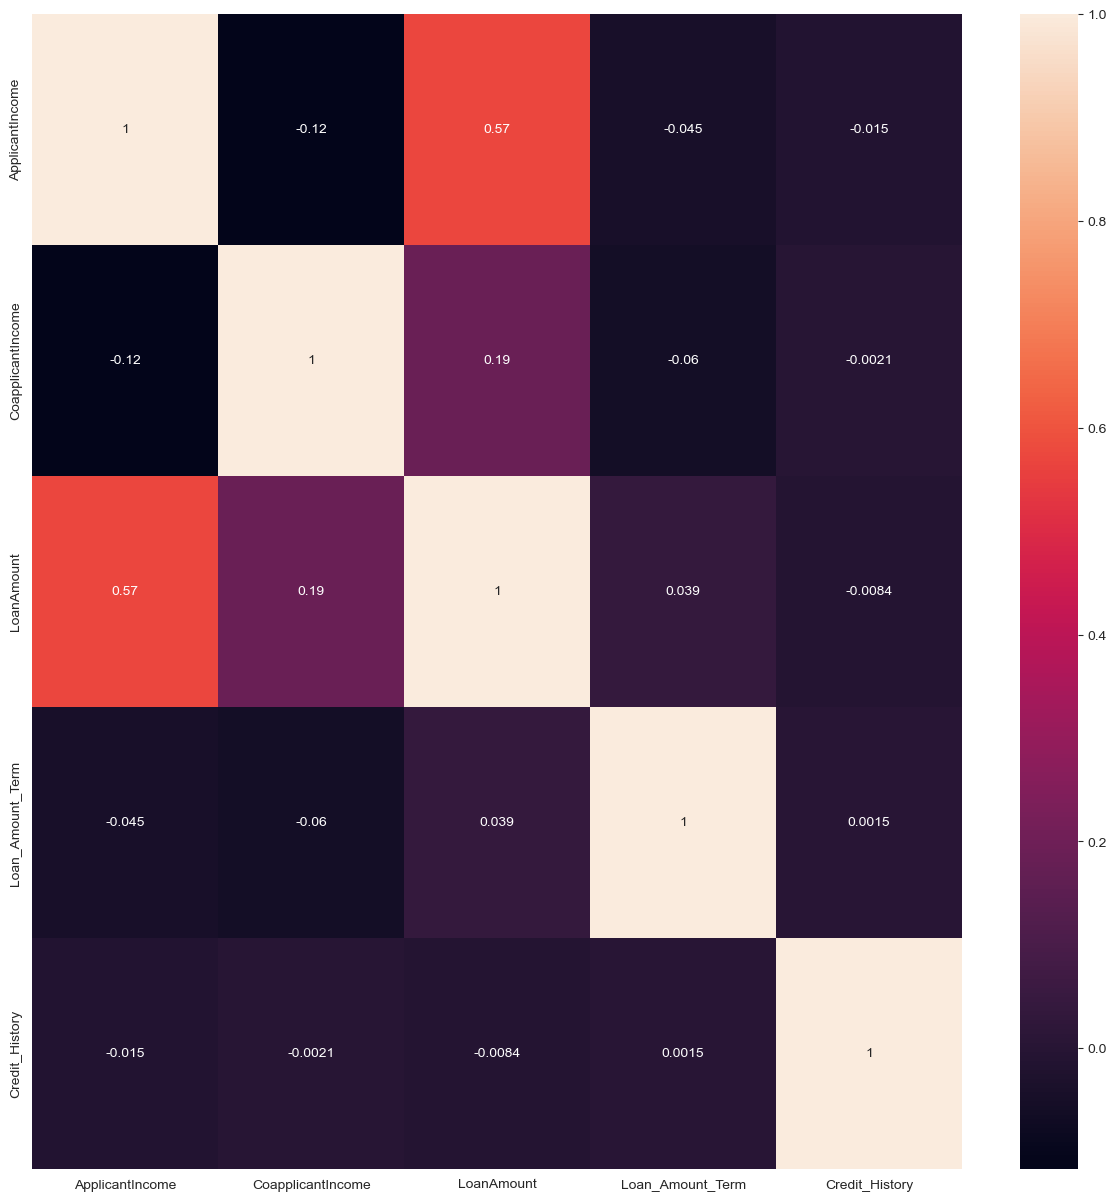

In [19]:
#plotting heatmap for checking multicoliinearity
plt.figure(figsize=(15,15))
sns.heatmap(df[numerical].corr(),annot=True)

Checking multicollinearity using VIF ....

BUT ,first extract and impute missing values..

In [20]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


Missing value treatment

In [21]:
df.isnull().sum()

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Gender--->Fill with mode

married--->fill with mode

Depenedent--->fill with mode

selfemployeed-->fill with mode

loanampount--->fill with median ,because data have outlier

loanamountterm-->fill with mode

credithistory-->fill with mode

In [22]:
df['Gender']=df['Gender'].fillna(df['Gender'].mode()[0])
df['Married']=df['Married'].fillna(df['Married'].mode()[0])
df['Dependents']=df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed']=df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['LoanAmount']=df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term']=df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History']=df['Credit_History'].fillna(df['Credit_History'].mode()[0])

In [23]:
df.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

Feature Extraction---

In [24]:
#data encoding

df['Gender']=df['Gender'].replace({
    "Male":1,
    "Female":0
})

df['Education']=df['Education'].replace({
    "Graduate":1,
    "Not Graduate":0
})

df['Self_Employed']=df['Self_Employed'].replace({
    "No":0,
    "Yes":1
})

df['Property_Area']=df['Property_Area'].replace({
    "Urban":1,
    "Semiurban":2,
    "Rural":3
})

df['Loan_Status']=df['Loan_Status'].replace({
    "Y":1,
    "N":0
})
df['Dependents']=df['Dependents'].replace({
    "1":1,
    "2":2,
    "3+":3
})

#here we should not encode married columns beacuse it totally depends on dependent column beacuse if its not  married then 
#its value will be 0 in dependent,otherwise numerical value

#Extracting new columns or Features


df['Total_Income']=df['ApplicantIncome']+df['CoapplicantIncome']
df["LoanAmount"]=df['LoanAmount']*1000
df['Loan_Amount_Term']=df['Loan_Amount_Term']/12

In [25]:
#Drop the irrevelant columns

df.drop(columns=['Married','ApplicantIncome','CoapplicantIncome'],axis=1,inplace=True)

In [26]:
#Now,rename and chnge the dataype of columns 
df['Gender']=df['Gender'].astype('int32')
df['Dependents']=df['Dependents'].astype('int32')
df['Education']=df['Education'].astype('int32')
df['LoanAmount']=df['LoanAmount'].astype('int64')
df['Loan_Amount_Term']=df['Loan_Amount_Term'].astype('int32')
df['Property_Area']=df['Property_Area'].astype('int32')
df['Loan_Status']=df['Loan_Status'].astype('int32')
df['Total_Income']=df['Total_Income'].astype('int32')

In [27]:
df

,Gender,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income
0,1,0,1,0,128000,30,1.0,1,1,5849
1,1,1,1,0,128000,30,1.0,3,0,6091
2,1,0,1,1,66000,30,1.0,1,1,3000
3,1,0,0,0,120000,30,1.0,1,1,4941
4,1,0,1,0,141000,30,1.0,1,1,6000
...,...,...,...,...,...,...,...,...,...,...
609,0,0,1,0,71000,30,1.0,3,1,2900
610,1,3,1,0,40000,15,1.0,3,1,4106
611,1,1,1,0,253000,30,1.0,1,1,8312
612,1,2,1,0,187000,30,1.0,1,1,7583


In [28]:
#Rename the columns:
df.rename(columns={
    "Dependents":"having_family",
    "LoanAmount":"Loan",
    "Loan_Amount_Term":"Repay(in years)",
    "Loan_Status":"Pass"
},inplace=True)

In [29]:
df

,Gender,having_family,Education,Self_Employed,Loan,Repay(in years),Credit_History,Property_Area,Pass,Total_Income
0,1,0,1,0,128000,30,1.0,1,1,5849
1,1,1,1,0,128000,30,1.0,3,0,6091
2,1,0,1,1,66000,30,1.0,1,1,3000
3,1,0,0,0,120000,30,1.0,1,1,4941
4,1,0,1,0,141000,30,1.0,1,1,6000
...,...,...,...,...,...,...,...,...,...,...
609,0,0,1,0,71000,30,1.0,3,1,2900
610,1,3,1,0,40000,15,1.0,3,1,4106
611,1,1,1,0,253000,30,1.0,1,1,8312
612,1,2,1,0,187000,30,1.0,1,1,7583


VIF is applied on continuous numerical features because it is calculated using linear regression, which measures linear relationships between numeric variables.

VIF=1/(1-R^2)

In [30]:
continious_feature=[col for col in df.columns if df[col].nunique()>=10]
print("len of continious_feature",len(continious_feature))

len of continious_feature 3


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           614 non-null    int32  
 1   having_family    614 non-null    int32  
 2   Education        614 non-null    int32  
 3   Self_Employed    614 non-null    int64  
 4   Loan             614 non-null    int64  
 5   Repay(in years)  614 non-null    int32  
 6   Credit_History   614 non-null    float64
 7   Property_Area    614 non-null    int32  
 8   Pass             614 non-null    int32  
 9   Total_Income     614 non-null    int32  
dtypes: float64(1), int32(7), int64(2)
memory usage: 31.3 KB


VIF

In [32]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
def Calculate_VIF(features,df):
    #feature of data
    X=df[features]
    #set constant for calculating VIF
    X['intercept']=1

    #create empty dataframe
    VIF=pd.DataFrame()
    VIF['variables']=X.columns

    VIF['VIF']=[variance_inflation_factor(X.values,i)for i in range(X.shape[1])]
    VIF=VIF[VIF['variables']!='intercept']
    return VIF
Calculate_VIF(continious_feature,df)


,variables,VIF
0,Loan,1.643055
1,Repay(in years),1.015931
2,Total_Income,1.649104


In [33]:
#There is no multicollinearity in this dataset|

<Axes: >

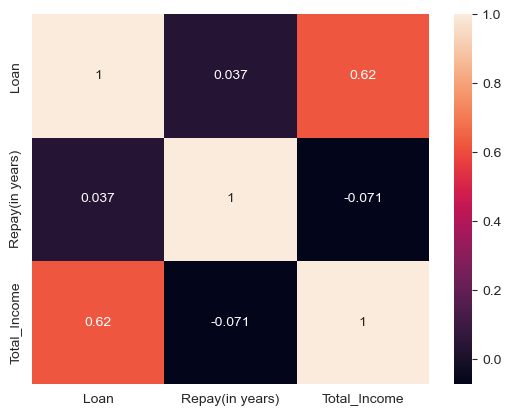

In [34]:
sns.heatmap(df[continious_feature].corr(),annot=True)

In [48]:
loan_fail=df[df['Pass']==0]['Total_Income'].mean()
loan_pass=df[df['Pass']==1]['Total_Income'].mean()

Report:

Low Income People have higher chance to getting loan,And average Income of people who are getting loan is 6888 rs

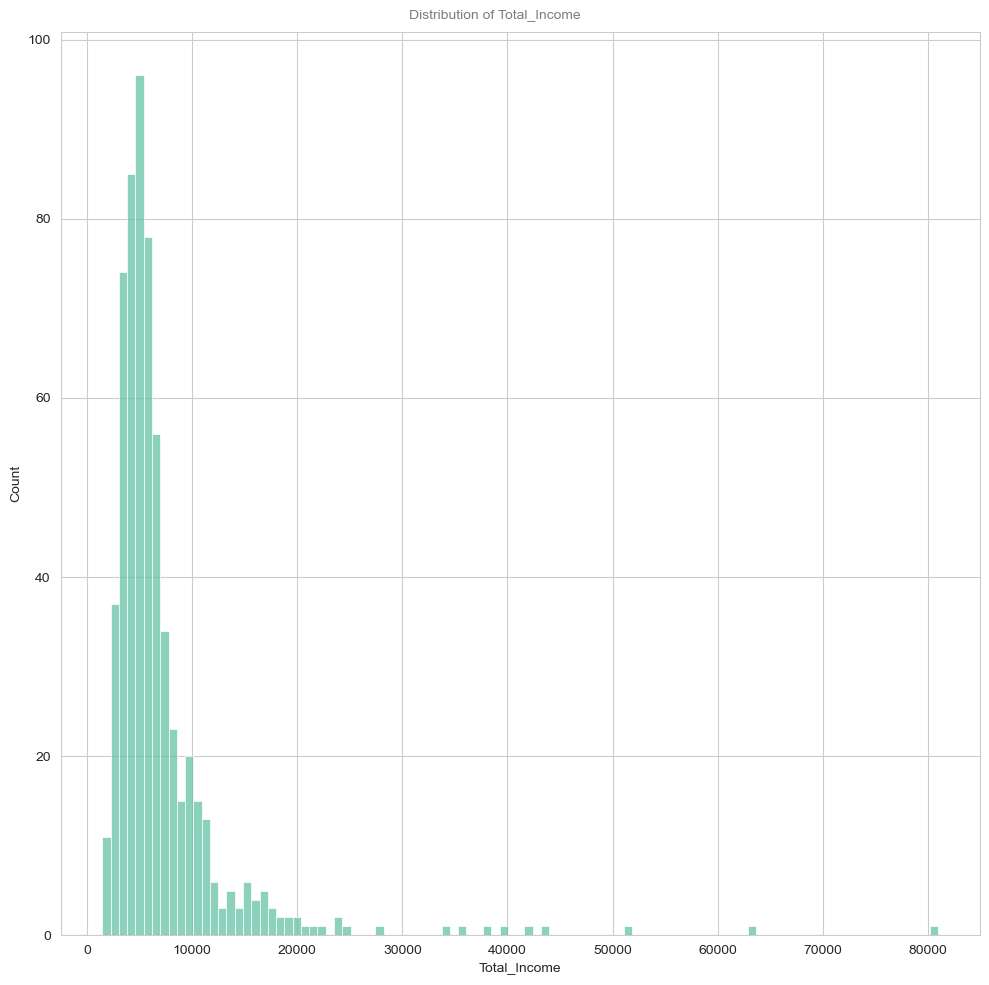

In [53]:
#Check thr distribution of Total_Income:
plt.figure(figsize=(10,10))
plt.suptitle('Distribution of Total_Income',fontsize=10,alpha=0.6)
sns.histplot(x=df['Total_Income'])
plt.xlabel('Total_Income')
plt.tight_layout()
plt.show()


# Report:

1-->Most people lies in range 0 to 20000 rs

2--->Presence of Outliers 

3--->Distribution is right skewed


In [76]:
#Checking for family size and their mean total income
Data=df[['having_family','Total_Income']]
Data.groupby('having_family')['Total_Income'].agg(['mean','min','max'])

,mean,min,max
having_family,,,
0,6529.561111,1442,63337
1,7388.509804,1880,37719
2,6614.019802,2281,21600
3,10605.529412,1830,81000


Report:

1-->People having family are earning more income

In [82]:
#now check for family size,total_income,and loan approved or not...
Data=df[['having_family','Total_Income','Pass']]
Data.groupby('having_family').agg({
    "Total_Income":'mean',
    "Pass":'count'
})

,Total_Income,Pass
having_family,,
0,6529.561111,360
1,7388.509804,102
2,6614.019802,101
3,10605.529412,51


Report:

1-->if you have less Income and single then getting a loan is easier,followed by 1,2,3


In [83]:
df

,Gender,having_family,Education,Self_Employed,Loan,Repay(in years),Credit_History,Property_Area,Pass,Total_Income
0,1,0,1,0,128000,30,1.0,1,1,5849
1,1,1,1,0,128000,30,1.0,3,0,6091
2,1,0,1,1,66000,30,1.0,1,1,3000
3,1,0,0,0,120000,30,1.0,1,1,4941
4,1,0,1,0,141000,30,1.0,1,1,6000
...,...,...,...,...,...,...,...,...,...,...
609,0,0,1,0,71000,30,1.0,3,1,2900
610,1,3,1,0,40000,15,1.0,3,1,4106
611,1,1,1,0,253000,30,1.0,1,1,8312
612,1,2,1,0,187000,30,1.0,1,1,7583


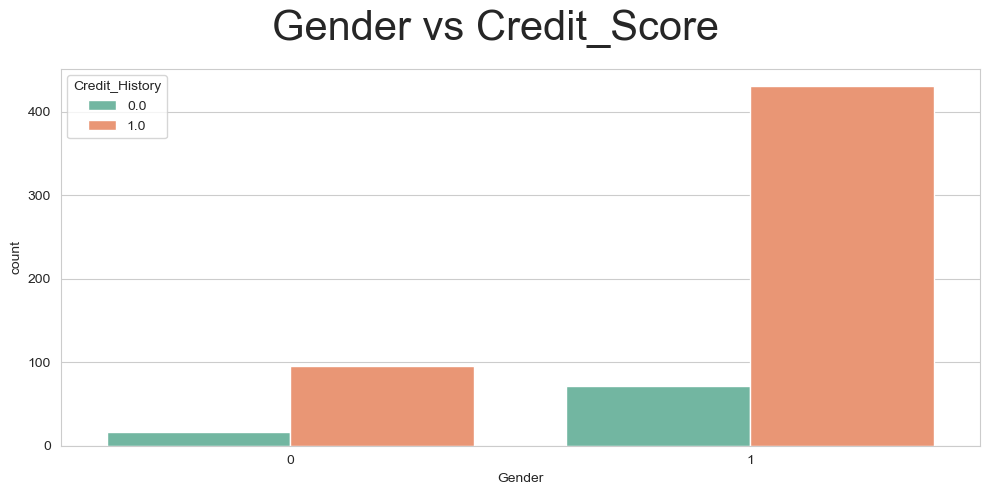

In [87]:
#checking who has better credit history for repay the loan
plt.figure(figsize=(10,5))
plt.suptitle('Gender vs Credit_Score',fontsize=30)
sns.countplot(x=df['Gender'],hue=df['Credit_History'])
plt.xlabel('Gender')
plt.tight_layout()
plt.show()

Report:

Male has better credit history than women for repay the loan

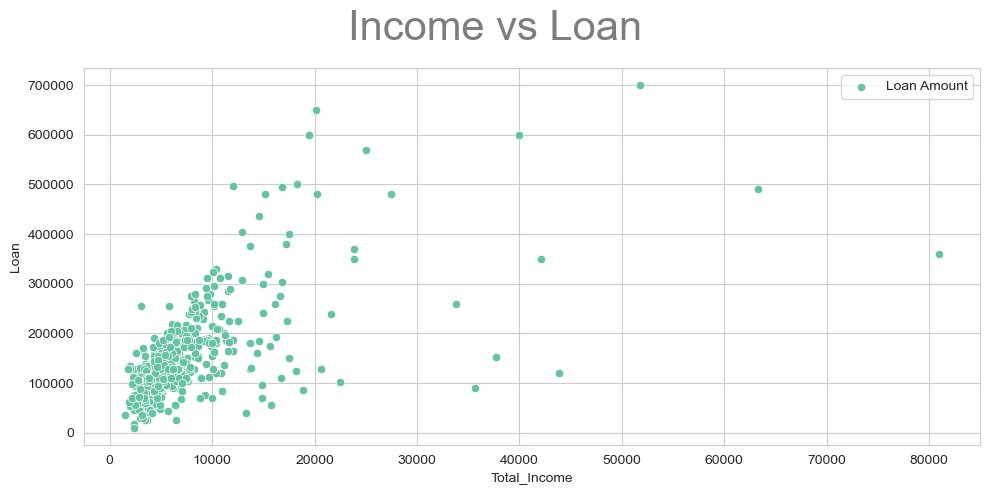

In [96]:
#now have a look on Total Income and Loan they are applied 
plt.figure(figsize=(10,5))
plt.suptitle('Income vs Loan',fontsize=30,alpha=0.6)
sns.scatterplot(x=df['Total_Income'],y=df['Loan'],label='Loan Amount')
plt.legend()
plt.tight_layout()
plt.show()

Report:

They are close to linear relationship,if income increases then amount of loan is also increases

In [129]:
#Education 
df['Education'].value_counts(normalize=True)*100


Education
1    78.175896
0    21.824104
Name: proportion, dtype: float64

Report:

78% people are graduates who are applied for job rest are non-graduate

In [131]:
df

,Gender,having_family,Education,Self_Employed,Loan,Repay(in years),Credit_History,Property_Area,Pass,Total_Income
0,1,0,1,0,128000,30,1.0,1,1,5849
1,1,1,1,0,128000,30,1.0,3,0,6091
2,1,0,1,1,66000,30,1.0,1,1,3000
3,1,0,0,0,120000,30,1.0,1,1,4941
4,1,0,1,0,141000,30,1.0,1,1,6000
...,...,...,...,...,...,...,...,...,...,...
609,0,0,1,0,71000,30,1.0,3,1,2900
610,1,3,1,0,40000,15,1.0,3,1,4106
611,1,1,1,0,253000,30,1.0,1,1,8312
612,1,2,1,0,187000,30,1.0,1,1,7583


Final Report or Key Insight :

1-->Most applicants earn below 20,000 Rs.

2-->Income, co-applicant income, and loan amount contain outliers.

3--->Male and married applicants dominate loan applications.

4-->Graduated applicants apply more for loans.

5--->Most applicants have good credit history, which increases chances of loan approval.

6-->Income and loan amount have a positive relationship.

7-->Applicants with fewer dependents have higher chances of loan approval.
